In [ ]:
import os 
# Hack as apparently the notebook does not source by .bashrc... 
os.environ["PATH"] = os.path.expanduser("~/packages/ncpag2s-clc/") + ":" + os.environ["PATH"]
import numpy as np 

from datetime import timedelta 
from obspy import UTCDateTime

# Examples of how to retrieve profiles (G2S), use the tau-p package and simulate waveforms (NCPAProp)

## Import atmospheric profiles

Existing dates: [UTCDateTime(2022, 3, 1, 0, 0) UTCDateTime(2022, 3, 1, 6, 0)
 UTCDateTime(2022, 3, 1, 12, 0) UTCDateTime(2022, 3, 1, 18, 0)
 UTCDateTime(2022, 3, 2, 0, 0)]
RETURNING without creating new profiles...


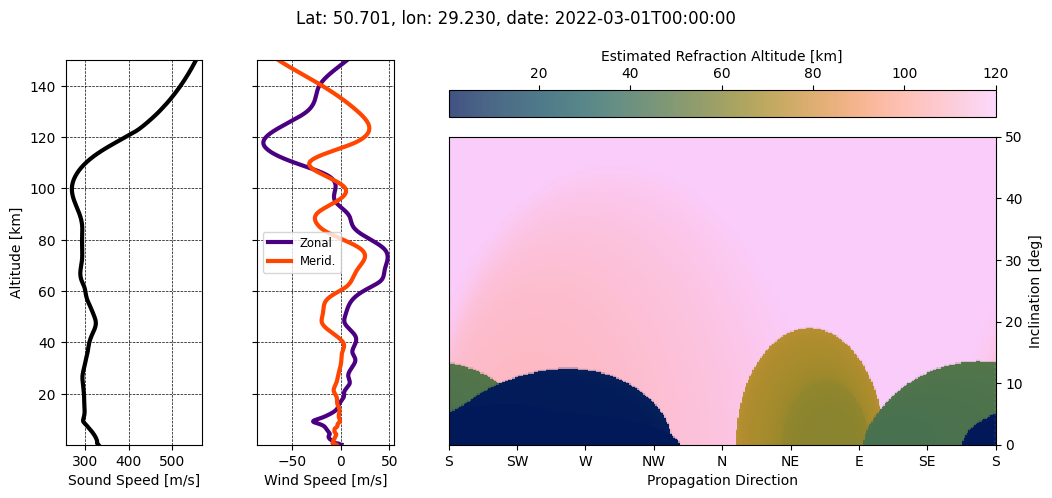

In [5]:
from infraprop.atmos import g2s_profile
from infraprop.utils import atmos_files 

# define your own directories where the data will be stored (one for grids and one for profiles)
grid_dir = "./data/test_grids/" 
profile_dir = "./data/test_profiles/"


# import profiles above MAAG in Ukraine for the first day in March 2022
station = "MAAG"
start_date = UTCDateTime("2022-03-01T00:00:00")
end_date = start_date + timedelta(days=1)
latlons = {
    "MAAG": (50.7014, 29.2301),
    "GRDI": (50.5993, 29.4471),
}
lat, lon = latlons[station]
h_resol = 6

G2S = g2s_profile.G2Sprofile(lat=lat, lon=lon, atmos_dir=profile_dir)
G2S.get_multiple_profiles(start_date, end_date, h_resol)
atm_profiles, atm_dates = atmos_files.list_g2s_files(profile_dir, lat, lon, start_date, end_date, h_resol)
G2S.plot_atm_profile(start_date) # Plotting stolen from infraGA :) 


## Use Tau-p to plot the profiles

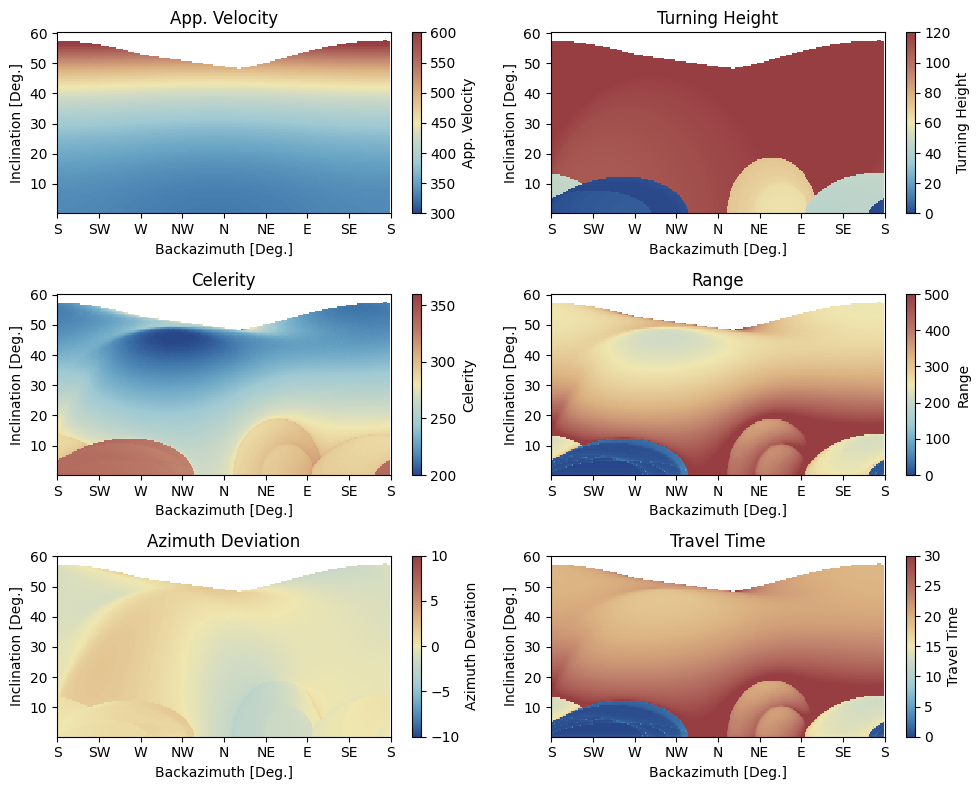

/staff/sophus/packages/infraprop/infraprop/raytracing/tau_p.py:325: RuntimeWarning: invalid value encountered in cast
  "arrival_idx": arrivals_idx.astype(int),


Ray paths time: 0.0199 seconds
Ray resolution: (60, 3002)


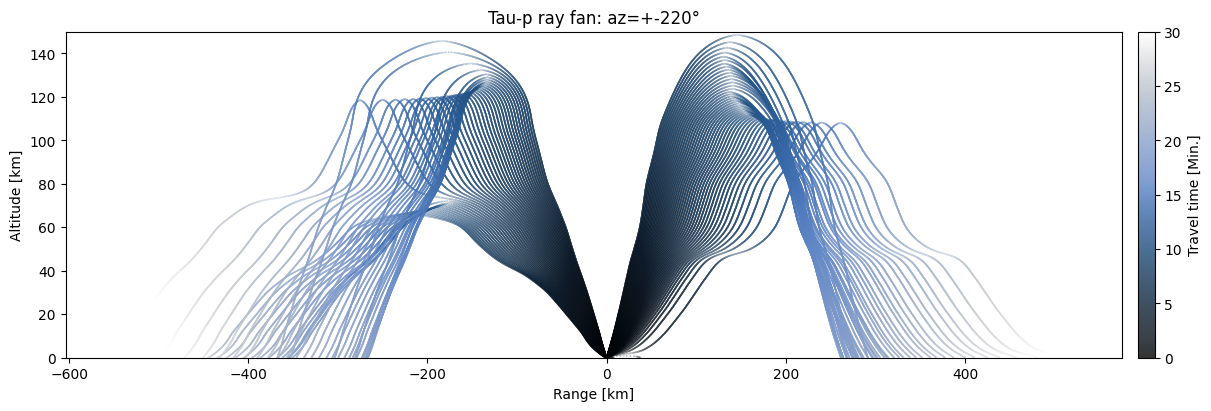

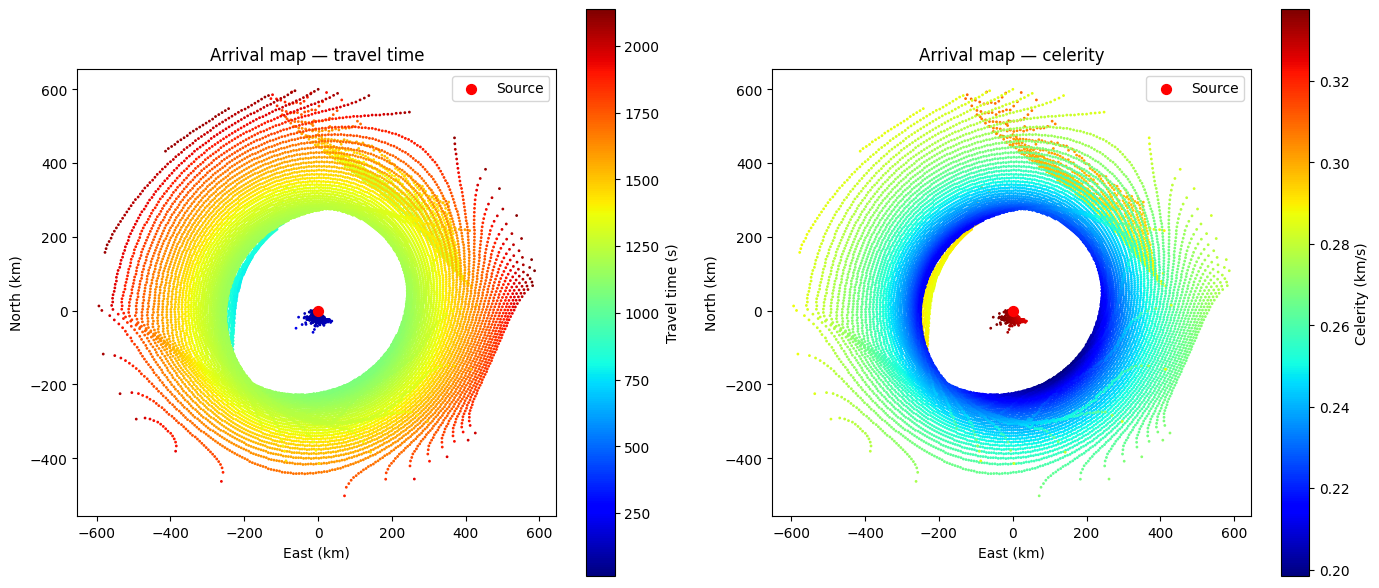

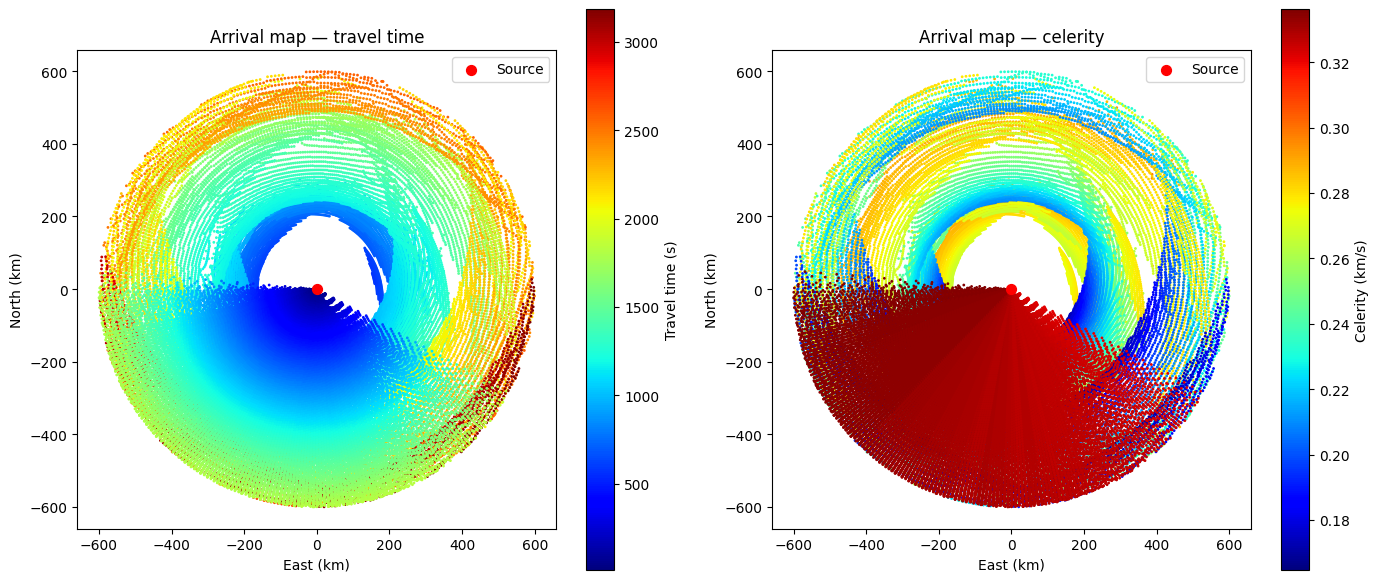

In [13]:
from infraprop.raytracing import tau_p

TauP = tau_p.TauP()
start_profile = os.path.join(profile_dir, atm_profiles[0])
TauP.plot_atm_profile(start_profile, gw=False, title=None, savefile=None, plot_c=False, block=True)
TauP.plot_ray_paths(az_deg=220, inc_degs=90 - np.arange(5, 65, 1), atm_profile=start_profile, gw=False) # NB: the inclinations are from the vertical --> thus the 90 - inc_degs

# Plot the first arrivals to the ground --> Note that it supports multiple bounces and GWs 
az_degs = np.arange(-180, 180, 1)
inc_degs = 90 - np.arange(5, 65, 1)
az_degs, inc_degs = np.meshgrid(az_degs, inc_degs)
az_degs, inc_degs = az_degs.flatten(), inc_degs.flatten()

TauP.plot_arrival_map(start_profile, az_degs=az_degs, inc_degs=inc_degs, gw=False, max_range_km=600, multiple_bounces=False)
TauP.plot_arrival_map(start_profile, az_degs=az_degs, inc_degs=inc_degs, gw=True, max_range_km=600, multiple_bounces=True)